In [6]:
import numpy as np

class GridWorldLikeSecretEnv:
    def __init__(self, rows=5, cols=5, terminal_states={4: -3.0, 24: 1.0}):
        self.rows = rows
        self.cols = cols
        self.n_states = rows * cols
        self.n_actions = 4  # 0: gauche, 1: droite, 2: haut, 3: bas
        self.rewards_dict = terminal_states
        self.terminal_states = list(terminal_states.keys())
        self.R = sorted(set(terminal_states.values()) | {0.0})
        self.state = 0  # position de départ : en haut à gauche
        self.action_names = ["left", "right", "up", "down"]

    def reset(self):
        self.state = 0

    def is_game_over(self):
        return self.state in self.terminal_states

    def num_states(self):
        return self.rows * self.cols

    def num_actions(self):
        return 4

    def num_rewards(self):
        return len(self.R)

    def reward(self, i):
        return self.R[i]

    def state_id(self):
        return self.state

    def is_forbidden(self, action):
        row, col = divmod(self.state, self.cols)
        if action == 0 and col == 0:
            return True  # gauche mur
        if action == 1 and col == self.cols - 1:
            return True  # droite mur
        if action == 2 and row == 0:
            return True  # haut mur
        if action == 3 and row == self.rows - 1:
            return True  # bas mur
        return False

    def available_actions(self):
        return np.array([a for a in range(self.n_actions) if not self.is_forbidden(a)])

    def step(self, action):
        if self.is_forbidden(action) or self.is_game_over():
            return  # pas de changement

        row, col = divmod(self.state, self.cols)
        if action == 0:
            col -= 1
        elif action == 1:
            col += 1
        elif action == 2:
            row -= 1
        elif action == 3:
            row += 1

        new_state = row * self.cols + col
        self.state = new_state

    def display(self):
        grid = np.full((self.rows, self.cols), ' . ')
        r, c = divmod(self.state, self.cols)
        grid[r, c] = ' A '
        for s, val in self.rewards_dict.items():
            r_t, c_t = divmod(s, self.cols)
            grid[r_t, c_t] = f'{val:+.0f}'
        return grid

env_test = GridWorldLikeSecretEnv()
env_test.display()


array([[' A ', ' . ', ' . ', ' . ', '-3'],
       [' . ', ' . ', ' . ', ' . ', ' . '],
       [' . ', ' . ', ' . ', ' . ', ' . '],
       [' . ', ' . ', ' . ', ' . ', ' . '],
       [' . ', ' . ', ' . ', ' . ', '+1']], dtype='<U3')

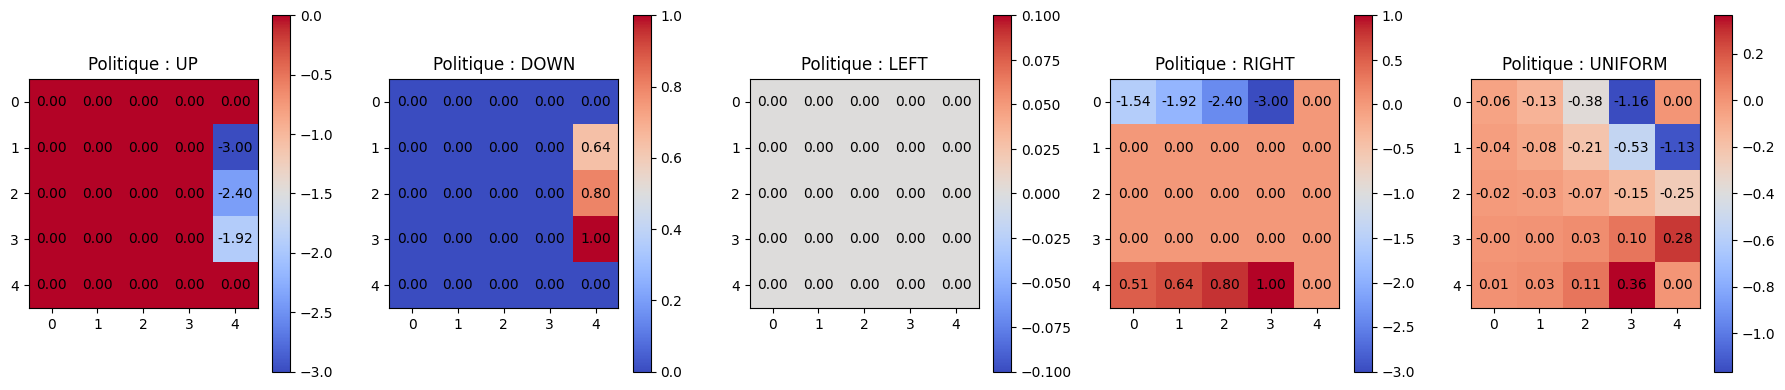

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# === Environnement GridWorld déclaré comme un MDP avec actions disponibles ===
class GridWorld:
    def __init__(self, rows=5, cols=5, terminal_states=[4, 24], rewards={4: -3.0, 24: 1.0}):
        self.rows = rows
        self.cols = cols
        self.n_states = rows * cols
        self.n_actions = 4  # 0: gauche, 1: droite, 2: haut, 3: bas
        self.terminal_states = terminal_states
        self.rewards_dict = rewards
        self.R = sorted(list(set(rewards.values()) | {0.0}))

        # Actions disponibles par état
        self.valid_actions_dict = {}
        self.model = {}
        self._build_transitions()

    def _state_to_coords(self, state):
        return state // self.cols, state % self.cols

    def _coords_to_state(self, row, col):
        return row * self.cols + col

    def _build_transitions(self):
        for s in range(self.n_states):
            if s in self.terminal_states:
                continue
            row, col = self._state_to_coords(s)
            self.valid_actions_dict[s] = []
            self.model[s] = {}

            for a in range(self.n_actions):
                new_row, new_col = row, col
                if a == 0 and col > 0:  # gauche
                    new_col -= 1
                elif a == 1 and col < self.cols - 1:  # droite
                    new_col += 1
                elif a == 2 and row > 0:  # haut
                    new_row -= 1
                elif a == 3 and row < self.rows - 1:  # bas
                    new_row += 1

                s_next = self._coords_to_state(new_row, new_col)
                r = self.rewards_dict.get(s_next, 0.0)
                self.model[s][a] = [(1.0, s_next, r)]
                self.valid_actions_dict[s].append(a)

    def get_mdp(self):
        return list(range(self.n_states)), list(range(self.n_actions)), self.R, self.model, self.valid_actions_dict

    def get_terminal_states(self):
        return self.terminal_states

# === Algorithme Iterative Policy Evaluation version Sparse ===
def iterative_policy_evaluation_sparse(
    pi: np.ndarray,
    S: list,
    A: list,
    model: dict,
    terminal_states: list,
    valid_actions_dict: dict,
    gamma: float = 0.8, #0.99,0.5,0.8
    theta: float =1e-4  #1e-2,1e-6,1e-4
):
    V = np.zeros(max(S)+1)
    while True:
        delta = 0.0
        for s in S:
            if s in terminal_states:
                continue
            v = V[s]
            total = 0.0
            for a in valid_actions_dict.get(s, A):
                for (prob, s_p, r) in model[s][a]:
                    total += pi[s, a] * prob * (r + gamma * V[s_p])
            V[s] = total
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break
    return V

# === Fonction d'affichage des valeurs d’états sous forme de grille ===
def plot_policy_values(results, env):
    fig, axs = plt.subplots(1, len(results), figsize=(18, 4))
    if len(results) == 1:
        axs = [axs]

    for ax, (name, V_grid) in zip(axs, results.items()):
        im = ax.imshow(V_grid, cmap='coolwarm', origin='upper')
        ax.set_title(f'Politique : {name}')
        for i in range(env.rows):
            for j in range(env.cols):
                ax.text(j, i, f'{V_grid[i, j]:.2f}', ha='center', va='center', color='black')
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# === Test de l’algorithme avec plusieurs politiques ===
if __name__ == "__main__":
    env = GridWorld()
    S, A, R, model, valid_actions_dict = env.get_mdp()
    terminal_states = env.get_terminal_states()

    # Initialisation des politiques fixes
    policies = {}
    directions = {'UP': 2, 'DOWN': 3, 'LEFT': 0, 'RIGHT': 1}

    for name, action in directions.items():
        pi = np.zeros((max(S)+1, len(A)))
        for s in S:
            if s in terminal_states:
                continue
            if action in valid_actions_dict.get(s, []):
                pi[s, action] = 1.0
        policies[name] = pi

    # Politique uniforme
    pi_uniform = np.zeros((max(S)+1, len(A)))
    for s in S:
        if s in terminal_states:
            continue
        valid = valid_actions_dict.get(s, [])
        for a in valid:
            pi_uniform[s, a] = 1.0 / len(valid)
    policies["UNIFORM"] = pi_uniform

    # Lancement des évaluations
    results = {}
    for name, pi in policies.items():
        V = iterative_policy_evaluation_sparse(
            pi=pi,
            S=S,
            A=A,
            model=model,
            terminal_states=terminal_states,
            valid_actions_dict=valid_actions_dict
        )
        results[name] = V[:env.n_states].reshape((env.rows, env.cols))

    # Affichage
    plot_policy_values(results, env)


In [17]:
import numpy as np

# --- Algorithme Policy Iteration (Sparse) ---
def policy_iteration_sparse(
    S, A, R, model, terminal_states, valid_actions_dict,
    theta=1e-4, gamma=0.99
):
    V = np.zeros(max(S) + 1)

    # Initialisation politique avec actions valides seulement
    pi = np.zeros(max(S) + 1, dtype=int)
    for s in S:
        if s in terminal_states or not valid_actions_dict.get(s):
            pi[s] = 0
        else:
            pi[s] = np.random.choice(valid_actions_dict[s])

    while True:
        # Policy Evaluation
        while True:
            delta = 0.0
            for s in S:
                if s in terminal_states:
                    continue
                a = pi[s]
                total = 0.0
                for prob, s_p, r in model[s][a]:
                    total += prob * (r + gamma * V[s_p])
                delta = max(delta, abs(V[s] - total))
                V[s] = total
            if delta < theta:
                break

        # Policy Improvement
        policy_stable = True
        for s in S:
            if s in terminal_states:
                continue
            old_action = pi[s]
            best_action = None
            best_value = -np.inf
            for a in valid_actions_dict.get(s, []):
                total = 0.0
                for prob, s_p, r in model[s][a]:
                    total += prob * (r + gamma * V[s_p])
                if total > best_value:
                    best_value = total
                    best_action = a
            if best_action is not None:
                pi[s] = best_action
            if pi[s] != old_action:
                policy_stable = False

        if policy_stable:
            break

    return pi, V

# --- Fonctions d'affichage ---
def print_policy(pi, rows, cols, label="Politique"):
    arrow = {0: "←", 1: "→", 2: "↑", 3: "↓"}
    print(f"\n=== {label} ===")
    for r in range(rows):
        ligne = ""
        for c in range(cols):
            s = r * cols + c
            a = pi[s]
            ligne += f"  {arrow.get(a, '.'):<2} "
        print(ligne)

def print_grid(V, rows, cols, label="Valeur des états"):
    print(f"\n=== {label} ===")
    for r in range(rows):
        ligne = ""
        for c in range(cols):
            s = r * cols + c
            ligne += f"{V[s]:6.2f} |"
        print(ligne)

# --- Classe GridWorld avec actions disponibles / interdites ---
class GridWorld:
    def __init__(self, rows=5, cols=5, terminal_states=[4, 24], rewards={4: -3.0, 24: 1.0}):
        self.rows = rows
        self.cols = cols
        self.n_states = rows * cols
        self.n_actions = 4  # gauche, droite, haut, bas
        self.terminal_states = terminal_states
        self.rewards_dict = rewards
        self.R = sorted(list(set(rewards.values()) | {0.0}))
        self.states = list(range(self.n_states))
        self.actions = list(range(self.n_actions))
        self.model = {}
        self.valid_actions = {}

        self._build_model()

    def _state_to_coords(self, s):
        return divmod(s, self.cols)

    def _coords_to_state(self, row, col):
        return row * self.cols + col

    def _build_model(self):
        for s in self.states:
            self.model[s] = {}
            self.valid_actions[s] = []
            if s in self.terminal_states:
                continue
            row, col = self._state_to_coords(s)
            for a in self.actions:
                new_row, new_col = row, col
                if a == 0 and col > 0: new_col -= 1  # gauche
                elif a == 1 and col < self.cols - 1: new_col += 1  # droite
                elif a == 2 and row > 0: new_row -= 1  # haut
                elif a == 3 and row < self.rows - 1: new_row += 1  # bas
                else:
                    continue  # action interdite

                s_p = self._coords_to_state(new_row, new_col)
                reward = self.rewards_dict.get(s_p, 0.0)
                self.model[s].setdefault(a, []).append((1.0, s_p, reward))
                self.valid_actions[s].append(a)

# --- Main ---
if __name__ == "__main__":
    env = GridWorld()
    S = env.states
    A = env.actions
    R = env.R
    model = env.model
    terminal_states = env.terminal_states
    valid_actions_dict = env.valid_actions

    pi, V = policy_iteration_sparse(
        S=S,
        A=A,
        R=R,
        model=model,
        terminal_states=terminal_states,
        valid_actions_dict=valid_actions_dict,
        theta=1e-4,
        gamma=0.99
    )

    print_policy(pi, env.rows, env.cols, label="Politique optimale")
    print_grid(V, env.rows, env.cols, label="Valeur optimale des états")



=== Politique optimale ===
  →    →    →    ↓    ←  
  →    →    →    →    ↓  
  →    →    →    →    ↓  
  →    →    →    →    ↓  
  →    →    →    →    ←  

=== Valeur optimale des états ===
  0.93 |  0.94 |  0.95 |  0.96 |  0.00 |
  0.94 |  0.95 |  0.96 |  0.97 |  0.98 |
  0.95 |  0.96 |  0.97 |  0.98 |  0.99 |
  0.96 |  0.97 |  0.98 |  0.99 |  1.00 |
  0.97 |  0.98 |  0.99 |  1.00 |  0.00 |
